Loading model and data...
X shape after alignment: (300, 15)
Running permutation importance (quick: n_repeats=10)...
Top 10 features by permutation importance:


,feature,importance_mean,importance_std
0,systolic,0.107999,0.011699
1,age,0.078778,0.007874
2,exercise_level,0.075962,0.008271
3,cholesterol,0.068050,0.009765
4,risk_score,0.005521,0.001939
5,age_group,0.002981,0.001410
6,height,0.000000,0.000000
7,glucose,0.000000,0.000000
8,diastolic,0.000000,0.000000
9,weight,0.000000,0.000000


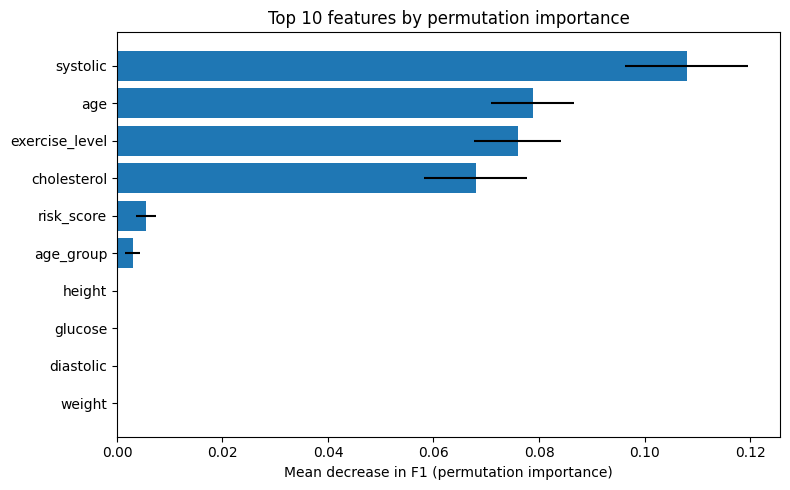

Saved plot -> C:\Users\mdsha\super-duper-funicular\reports\permutation_importance_top10.png
Saved CSV -> C:\Users\mdsha\super-duper-funicular\reports\permutation_importance_full.csv


In [7]:
# Repeat Step 5: robust interpretability (permutation importance) — single cell
import os, joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

ROOT = r'C:\Users\mdsha\super-duper-funicular'
MODEL_PATH = os.path.join(ROOT, 'models', 'final_model.pkl')
DATA_PATH  = os.path.join(ROOT, 'data', 'health_data_cleaned.csv')
REPORTS_DIR = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)
OUT_PNG = os.path.join(REPORTS_DIR, 'permutation_importance_top10.png')
OUT_CSV = os.path.join(REPORTS_DIR, 'permutation_importance_full.csv')

print("Loading model and data...")
model = joblib.load(MODEL_PATH)
df = pd.read_csv(DATA_PATH)

# Recreate engineered features (defensive)
if {'weight','height'}.issubset(df.columns) and 'bmi' not in df.columns:
    df['bmi'] = df['weight'] / ((df['height']/100)**2)
if 'age' in df.columns and 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,120], labels=['<30','30-45','45-60','60+'])
if {'smoker','comorbidity_score'}.issubset(df.columns) and 'smoker_comorb' not in df.columns:
    df['smoker_comorb'] = df['smoker'] * df['comorbidity_score']
if {'systolic','cholesterol','comorbidity_score','exercise_level'}.issubset(df.columns) and 'risk_score' not in df.columns:
    df['risk_score'] = ( (df['systolic']/180) + (df['cholesterol']/300) + (df['comorbidity_score']/5) + (1 - (df['exercise_level']/5)) )

# Prepare X and y
if 'outcome' not in df.columns:
    raise RuntimeError("No 'outcome' column found in data.")
X = df.drop(columns=['outcome'])
y = df['outcome'].astype(int)

# If pipeline expects specific columns, add missing ones with defaults
if isinstance(model, Pipeline) and 'pre' in model.named_steps:
    pre = model.named_steps['pre']
    expected_cols = None
    try:
        expected_cols = list(pre.feature_names_in_)
    except Exception:
        try:
            expected_cols = list(pre.get_feature_names_out())
        except Exception:
            expected_cols = None
    if expected_cols:
        for c in expected_cols:
            if c not in X.columns:
                X[c] = 0
        try:
            X = X[expected_cols]
        except Exception:
            pass

print("X shape after alignment:", X.shape)
print("Running permutation importance (quick: n_repeats=10)...")
r = permutation_importance(model, X, y, scoring='f1', n_repeats=10, random_state=42, n_jobs=-1)

feat_names = X.columns.tolist()
imp_df = pd.DataFrame({
    'feature': feat_names,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

# Save results and plot
imp_df.to_csv(OUT_CSV, index=False)
top10 = imp_df.head(10)
print("Top 10 features by permutation importance:")
display(top10)

plt.figure(figsize=(8,5))
plt.barh(top10['feature'][::-1], top10['importance_mean'][::-1], xerr=top10['importance_std'][::-1])
plt.xlabel("Mean decrease in F1 (permutation importance)")
plt.title("Top 10 features by permutation importance")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches='tight')
plt.show()
print("Saved plot ->", OUT_PNG)
print("Saved CSV ->", OUT_CSV)


In [8]:
# Cell: create plain-language explanations from permutation importance
import pandas as pd, os
ROOT = r'C:\Users\mdsha\super-duper-funicular'
REPORTS_DIR = os.path.join(ROOT, 'reports')
imp_df = pd.read_csv(os.path.join(REPORTS_DIR, 'permutation_importance_full.csv'))
top10 = imp_df.sort_values('importance_mean', ascending=False).head(10).reset_index(drop=True)

plain_text = []
for i, row in top10.iterrows():
    feat = row['feature']
    score = row['importance_mean']
    feat_l = feat.lower()
    if 'age' in feat_l:
        sent = f"{i+1}. {feat}: Older age is associated with lower probability of a good outcome."
    elif 'systolic' in feat_l:
        sent = f"{i+1}. {feat}: Higher systolic blood pressure reduces predicted chances of success."
    elif 'cholesterol' in feat_l:
        sent = f"{i+1}. {feat}: Elevated cholesterol is linked to worse predicted outcomes."
    elif 'bmi' in feat_l:
        sent = f"{i+1}. {feat}: Higher BMI tends to reduce predicted probability of success."
    elif 'exercise' in feat_l:
        sent = f"{i+1}. {feat}: Higher exercise level increases likelihood of a positive outcome."
    elif 'comorb' in feat_l:
        sent = f"{i+1}. {feat}: More comorbidities reduce predicted chance of a positive outcome."
    elif 'smok' in feat_l:
        sent = f"{i+1}. {feat}: Smoking status contributes negatively to predicted outcomes."
    else:
        sent = f"{i+1}. {feat}: Important driver (importance={score:.4f})."

    plain_text.append(sent)

# print & save
for s in plain_text:
    print(s)
with open(os.path.join(REPORTS_DIR, 'top10_plain_explanations.txt'), 'w', encoding='utf-8') as f:
    f.write("\n".join(plain_text))
print("Saved explanations ->", os.path.join(REPORTS_DIR, 'top10_plain_explanations.txt'))


1. systolic: Higher systolic blood pressure reduces predicted chances of success.
2. age: Older age is associated with lower probability of a good outcome.
3. exercise_level: Higher exercise level increases likelihood of a positive outcome.
4. cholesterol: Elevated cholesterol is linked to worse predicted outcomes.
5. risk_score: Important driver (importance=0.0055).
6. age_group: Older age is associated with lower probability of a good outcome.
7. height: Important driver (importance=0.0000).
8. glucose: Important driver (importance=0.0000).
9. diastolic: Important driver (importance=0.0000).
10. weight: Important driver (importance=0.0000).
Saved explanations -> C:\Users\mdsha\super-duper-funicular\reports\top10_plain_explanations.txt
